# Levene Test for Equal Variances

The **Levene test** is a robust alternative to Bartlett's test that does not assume normality. It works by transforming each observation into its absolute deviation from the group median, then running a one-way ANOVA on those deviations.

| Property | Value |
|---|---|
| **H₀** | σ₁² = σ₂² = ⋯ = σₖ² |
| **H₁** | At least one variance differs |
| **Transformation** | z_ij = |y_ij − median(group_i)| |
| **Test statistic** | F-statistic from one-way ANOVA on z_ij |
| **Robust to** | Non-normality, heavy tails, skewness |
| **vs Bartlett** | Levene: robust but less powerful when data is truly normal |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

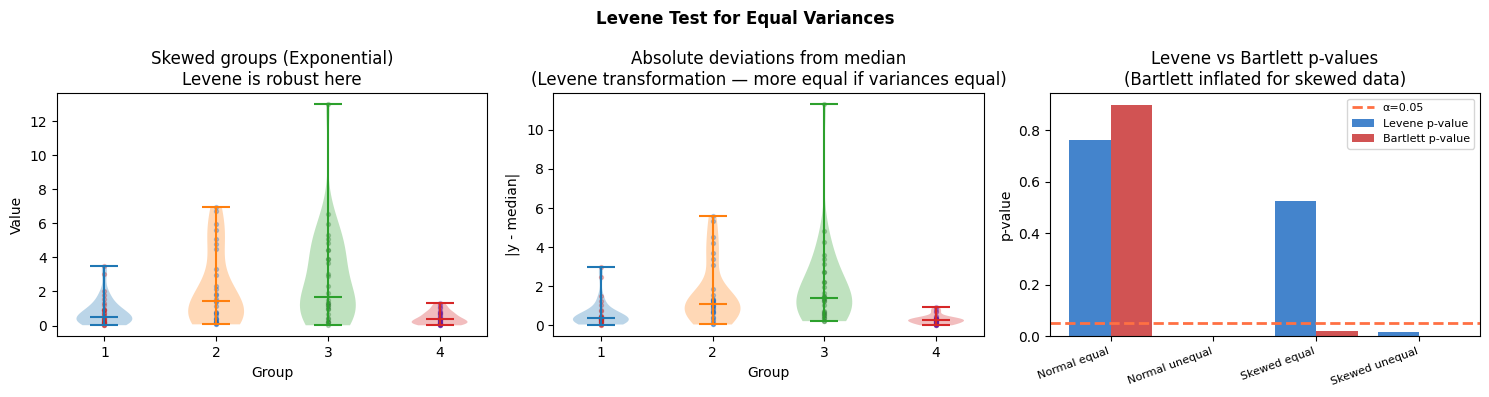

Skewed groups: Levene p=0.0000, Bartlett p=0.0000
(Bartlett p is unreliable for skewed data)


In [2]:
np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Levene Test for Equal Variances', fontsize=12, fontweight='bold')

k = 4; n = 30
# Skewed groups (exponential) with unequal scales
groups_skew = [stats.expon.rvs(scale=s, size=n) for s in [1.0, 2.0, 3.0, 0.5]]

lev_stat, lev_p = stats.levene(*groups_skew)
bar_stat, bar_p = stats.bartlett(*groups_skew)

# Panel 1: original distributions (skewed)
colors = ['#C62828', '#1565C0', '#2E7D32', '#6A1B9A']
for i, (g, color) in enumerate(zip(groups_skew, colors)):
    axes[0].violinplot(g, positions=[i+1], showmeans=False, showmedians=True)
    axes[0].scatter([i+1]*n, g, color=color, alpha=0.3, s=8)
axes[0].set_title('Skewed groups (Exponential)\nLevene is robust here')
axes[0].set_xlabel('Group'); axes[0].set_ylabel('Value')
axes[0].set_xticks(range(1, k+1))

# Panel 2: absolute deviations from median (Levene transformation)
z_groups = [np.abs(g - np.median(g)) for g in groups_skew]
for i, (z, color) in enumerate(zip(z_groups, colors)):
    axes[1].violinplot(z, positions=[i+1], showmeans=False, showmedians=True)
    axes[1].scatter([i+1]*n, z, color=color, alpha=0.3, s=8)
axes[1].set_title('Absolute deviations from median\n(Levene transformation — more equal if variances equal)')
axes[1].set_xlabel('Group'); axes[1].set_ylabel('|y - median|')
axes[1].set_xticks(range(1, k+1))

# Panel 3: compare Levene vs Bartlett
test_scenarios = ['Normal equal', 'Normal unequal', 'Skewed equal', 'Skewed unequal']
lev_ps, bar_ps = [], []
for _ in range(1):  # pre-compute for display
    pass
scenarios = [
    [np.random.normal(0, 2, n) for _ in range(k)],
    [np.random.normal(0, s, n) for s in [1, 2, 3, 4]],
    [stats.expon.rvs(scale=2, size=n) for _ in range(k)],
    [stats.expon.rvs(scale=s, size=n) for s in [1, 2, 3, 4]],
]
for grps in scenarios:
    lev_ps.append(stats.levene(*grps)[1])
    bar_ps.append(stats.bartlett(*grps)[1])

x_pos = np.arange(len(test_scenarios))
axes[2].bar(x_pos - 0.2, lev_ps, 0.4, color='#1565C0', alpha=0.8, label='Levene p-value')
axes[2].bar(x_pos + 0.2, bar_ps, 0.4, color='#C62828', alpha=0.8, label='Bartlett p-value')
axes[2].axhline(0.05, color='#FF7043', lw=2, ls='--', label='α=0.05')
axes[2].set_title('Levene vs Bartlett p-values\n(Bartlett inflated for skewed data)')
axes[2].set_xticks(x_pos); axes[2].set_xticklabels(test_scenarios, rotation=20, ha='right', fontsize=8)
axes[2].set_ylabel('p-value'); axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()
print(f'Skewed groups: Levene p={lev_p:.4f}, Bartlett p={bar_p:.4f}')
print('(Bartlett p is unreliable for skewed data)')

## Key Takeaways

| | |
|---|---|
| **Median-based** | Using median (not mean) makes Levene robust to skewness |
| **Prefer over Bartlett** | Unless data is known to be normal |
| **Fail to reject H₀** | Equal variances — safe to use pooled ANOVA |
| **Reject H₀** | Use Welch's ANOVA (not standard ANOVA) for unequal group sizes |
| **Visual companion** | Always pair with boxplots or SD plot to see which groups differ |
| **center='mean'** | Mean-based Levene (Brown-Forsythe) is slightly different — use median |